<a href="https://colab.research.google.com/github/Estobam989/Ihifix_AI-MLCOHORT/blob/main/Car_Price_Prediction_Wk2_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Used Car Price Prediction Using Linear Regression

**Business Problem**

The online car marketplace wants to estimate the selling price of used cars automatically based on vehicle characteristics. Accurate price prediction helps sellers list vehicles competitively and assists buyers in identifying fair market prices.

**Target Variable and Features**

Target Variable:
- Price

Potential Features:
- Brand

In [4]:
# import necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [6]:
df = pd.read_csv("/content/drive/MyDrive/Agentic class doc/Car_data_jtrjuw.csv")



In [7]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [8]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
# Missing Values
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


# **Interpretation**

There are no missing values in the dataset. Therefore, no rows or columns need to be removed due to missing data.

In [10]:
# Summary Statistics
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# **Visualizations**

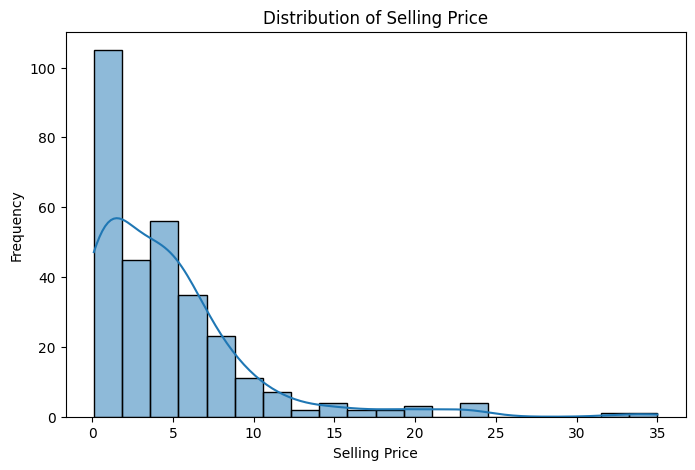

In [16]:
# Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Selling_Price'], bins=20, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")


plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

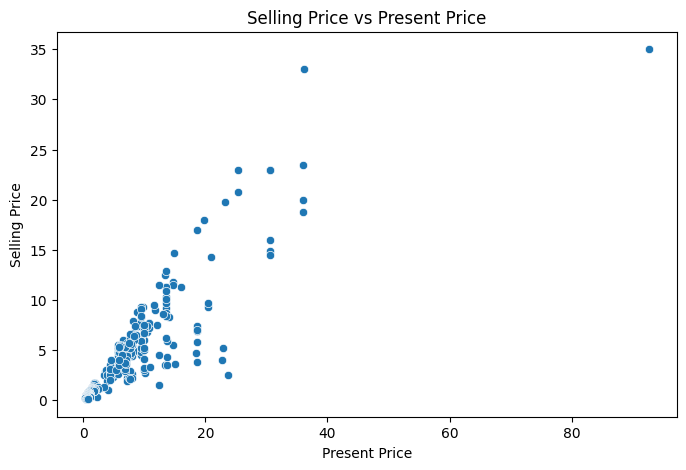

In [18]:
# Price vs Present Price
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Present_Price',
    y='Selling_Price',
    data=df
)

plt.title("Selling Price vs Present Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.show()

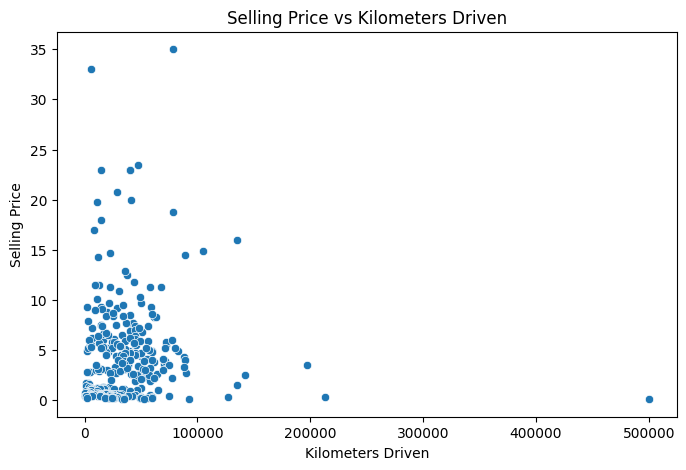

In [48]:
# Selling Price vs Kilometers Driven
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Kms_Driven",
    y="Selling_Price",
    data=df
)

plt.title("Selling Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.show()

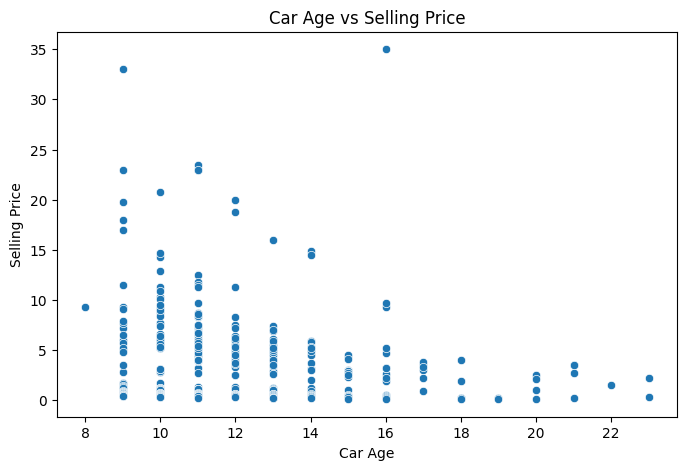

In [21]:
# Price vs Age of Car
current_year = 2026

df['Car_Age'] = current_year - df['Year']

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Car_Age',
    y='Selling_Price',
    data=df
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

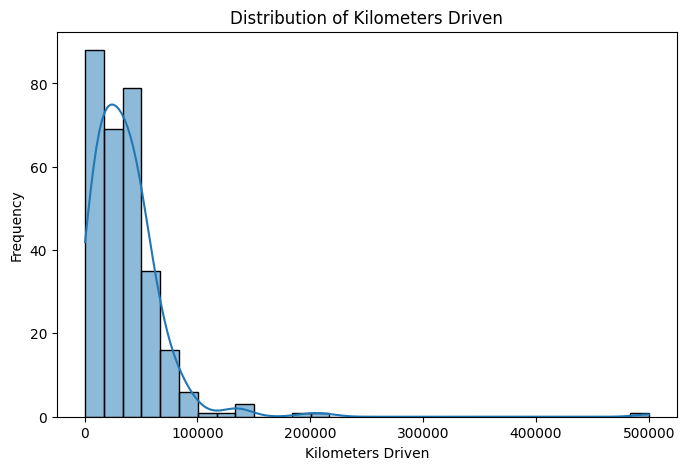

In [28]:
# Kms_Driven Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Kms_Driven'], bins=30, kde=True)
plt.title('Distribution of Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Frequency')
plt.show()

# **Data Preprocessing**

In [49]:
# Encode Categorical Variables
le = LabelEncoder()

df["Car_Name"] = le.fit_transform(df["Car_Name"])
df["Fuel_Type"] = le.fit_transform(df["Fuel_Type"])
df["Seller_Type"] = le.fit_transform(df["Seller_Type"])
df["Transmission"] = le.fit_transform(df["Transmission"])

In [50]:
# Define features (X) and target (y)
X = df.drop(['Selling_Price', 'Year'], axis=1)
y = df['Selling_Price']


In [51]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Scale the target variable as well
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

y_train = pd.Series(y_train_scaled.flatten(), name=y_train.name)
y_test = pd.Series(y_test_scaled.flatten(), name=y_test.name)

In [40]:
# Train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

# Make predictions on the test set (predictions will be scaled)
y_pred_scaled = linear_reg_model.predict(X_test)

# Inverse transform predictions and actual y_test to original scale for evaluation
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_original = y_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()

# Evaluate the model using original scale values
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 1.21
Mean Squared Error (MSE): 3.53
Root Mean Squared Error (RMSE): 1.88
R-squared (R2): 0.85


In [41]:
# Predict Price for 5 Sample Cars
sample_cars = X_test.head(5) # X_test is already scaled

predictions_scaled = linear_reg_model.predict(sample_cars)

# Inverse transform the scaled predictions to get actual prices
predictions = y_scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()

results = pd.DataFrame({
    'Predicted Price': predictions
})

print(results)

   Predicted Price
0         2.976445
1         8.329179
2         6.012304
3        -1.378052
4         9.280705


### Feature Importance

In [56]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_reg_model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,Present_Price,0.768821
0,Car_Name,-0.016582
2,Kms_Driven,-0.045650
6,Owner,-0.047629
7,Age,-0.101333
8,Car_Age,-0.101333
5,Transmission,-0.105451
3,Fuel_Type,-0.110264
4,Seller_Type,-0.121946


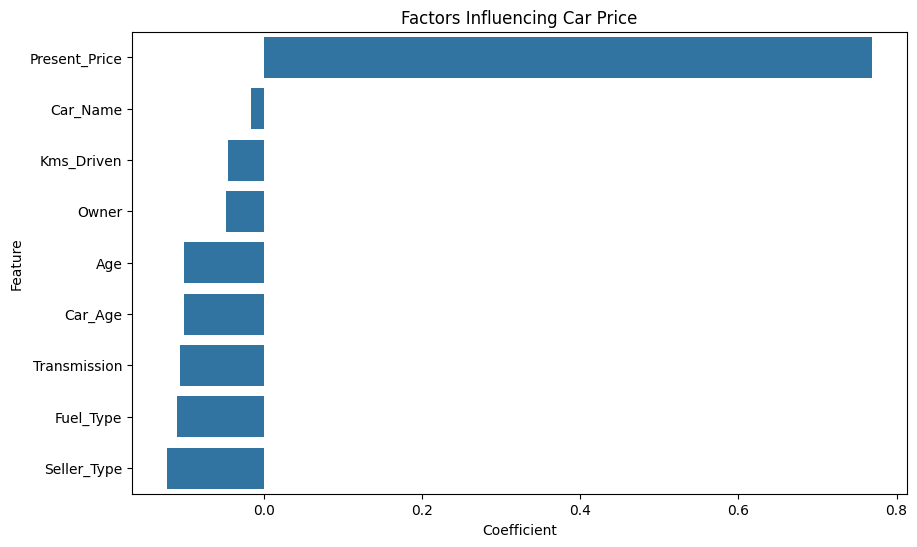

In [54]:
coef_plot = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coef_plot
)

plt.title("Factors Influencing Car Price")

plt.show()

# Insights

## What factors most influence car price?

The analysis shows that a vehicle's current market value (Present_Price) is the strongest predictor of its selling price. Cars with higher present market values consistently command higher resale prices. In contrast, vehicle age and total kilometers driven have a negative impact on price, reflecting the natural depreciation that occurs as cars get older and accumulate more usage. Additionally, factors such as transmission type, fuel type, and ownership history contribute to price variations, although their influence is less significant than the vehicle's market value and age.

## What surprised me in the data?

One interesting finding was that age alone does not determine a car's resale value. Several older vehicles maintained relatively strong selling prices despite being on the road for many years. This suggests that consumers consider other factors beyond age, such as brand reputation, reliability, fuel efficiency, maintenance history, and overall condition. The result highlights that depreciation is not always linear and that certain vehicles can retain their value better than others due to market demand and perceived quality.